# NB03 Data Transformation
## Sector Rotation & Federal Reserve Rate Cycles
### DS105W Data for Data Science | Group Project 2025–2026

<div style="font-family:system-ui; padding:16px 24px; background:#FFFFFF;
     border-left:8px solid #ED9255; border-radius:8px;
     box-shadow:0 4px 12px rgba(0,0,0,0.08); max-width:640px; color:#212121">

**Team:** Git It Done

| Member | Role | Notebook |
|--------|------|----------|
| Hugo Whyte | Data Collection | NB01 |
| Parthiv Chakadath | Cleaning & Database | NB02 |
| **Joel Saldanha** | Analysis & Website |  **This notebook**  |

**Research Question:** *How do US equity sector returns vary across Federal Reserve rate hiking and cutting cycles, and which sectors consistently rotate into outperformance as monetary policy shifts?*


## Decisions Made Before Writing Any Code

Following the same workflow Hugo used in NB01 and Parthiv used in NB02, I document the analysis decisions upfront so the choices are transparent and reviewable.


---

### 1 · Inputs and Outputs

| Direction | Path | Format |
|-----------|------|--------|
| Read | `data/processed/sector_rotation.db` | SQLite |
| Write | `data/processed/analysis/cycle_returns.csv` | CSV |
| Write | `data/processed/analysis/sector_cycle_pivot.csv` | CSV |
| Write | `docs/figures/*.png` | PNG (150 dpi) |

NB03 reads only from the SQLite database and never touches the raw JSON. This continues the save-before-transform rule one stage further: NB01 writes raw, NB02 writes the database, NB03 writes the analysis outputs.

---

### 2 · Aggregation Grain


I aggregate by sector and rate_cycle. The two obvious alternatives are sector and month, which would give a time series of returns per sector and answer "how has each sector performed over time", or sector and year, which would smooth across regimes and answer "which sectors did well in 2008 versus 2015". Neither matches the research question, which is about how sectors behave conditional on the rate regime rather than conditional on the calendar. Regime is the natural way to group. I keep the time-series detail in the underlying SQL query for sanity checks but collapse it for the headline analysis.

---

### 3 · Return Measure


I report the annualised return as `(1 + mean_monthly) ** 12 - 1`, alongside the raw mean, median, standard deviation, and sample size.

Monthly returns of around 0.5% to 1% are hard to interpret for a non-specialist reader. Annualising makes the numbers legible, so a 0.8% monthly mean reads as roughly 10% annualised. The formula is the standard practitioner shortcut: it takes the arithmetic mean of monthly returns and compounds it 12 times, which is not identical to the true geometric mean of the underlying monthly series (that would be the product of `(1 + r_i)` to the power `1/n`, then to the 12th power). It's the standard practitioner shortcut and the raw monthly mean is kept visible in the table so anyone checking the work can compute the alternative if they want.

---

### 4 · Visualisation Count and Roles

The self-chosen track allows a maximum of three distinct visuals on the website. Each one has to do a job the others cannot.

| Visual | Job |
|--------|-----|
| Heatmap pivot | Full sector by cycle matrix with conditional formatting, the reference table |
| Bar chart (hiking vs cutting) | The headline finding, the cyclical and defensive flip across regimes |
| Fed Funds line with regime shading | Macro context, showing when each regime actually happened |

A fourth visual would just add noise. Dropping any of these three would lose either the detail (heatmap), the punchline (bar chart), or the context (timeline).

---

### 5 · Headline Chart Exclusions

The bar chart leaves out the neutral regime even though the heatmap includes it. Neutral only covers 41 months across 10 sectors, and those months cluster in calm late-cycle bull runs that flatter almost every sector. Including neutral in the headline chart would overstate how clean the regime contrast actually is. Keeping it in the heatmap means a reader who wants the full picture can still see it.

---

### 6 · Sector Ordering

Sectors are sorted left to right by hiking-cycle annualised return. This way the cyclical-to-defensive gradient reads naturally across the x-axis and a reader does not need to recognise sector tickers to follow the story. Real Estate ends up at the far right as a rate-sensitive defensive, which also keeps the XLRE small-sample sector visually separate.

---

### 7 · Limitations Disclosure Protocol

Three caveats apply to different parts of the analysis: the short XLRE history affects Real Estate cells, the crisis-driven cutting cycles affect the cutting column generally, and the small neutral sample size affects the neutral column. I put each caveat in the markdown cell directly above the visual it affects, rather than collecting them all in a footer at the end. Caveats are more useful next to the chart that needs them, where a reader is actually looking, than at the bottom of the notebook where they are easy to skip.

## Section 1: Imports

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅Libraries loaded successfully.")

✅Libraries loaded successfully.


## Section 2: Database Connection and Load

I first verify the database schema matches what NB02 handed over, then load the analysis dataframe using a SQL join rather than reading the two tables separately and merging in pandas. The join logic is the cleanest way to ask the question: for each sector-month, what was the macro regime? Doing it in SQL means the database stays the one place the relationship is defined, and NB03 reads a query result rather than rebuilding the link in pandas.

INNER JOIN drops any month where either side is missing, which is the right behaviour here. NB02 documented two known gaps (October 2025 CPI from the BLS shutdown, April 2026 from FRED publication lag) and INNER JOIN handles both cleanly without me having to handle them separately.

In [2]:
# Verify NB02's database matches the schema we expect before loading anything
conn = sqlite3.connect('../data/processed/sector_rotation.db')

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

for table in tables['name']:
    print(f"\n--- {table} ---")
    print(pd.read_sql(f"PRAGMA table_info({table})", conn))
    print(pd.read_sql(f"SELECT * FROM {table} LIMIT 3", conn))

conn.close()

               name
0  macro_indicators
1    sector_returns

--- macro_indicators ---
   cid          name  type  notnull dflt_value  pk
0    0          date  TEXT        0       None   1
1    1     fed_funds  REAL        0       None   0
2    2           cpi  REAL        0       None   0
3    3  yield_spread  REAL        0       None   0
4    4    rate_cycle  TEXT        1       None   0
         date  fed_funds    cpi  yield_spread rate_cycle
0  1993-01-01       3.02  142.8          2.21    neutral
1  1993-02-01       3.03  143.1          2.16    neutral
2  1993-03-01       3.07  143.3          2.03    neutral

--- sector_returns ---
   cid            name     type  notnull dflt_value  pk
0    0              id  INTEGER        0       None   1
1    1            date     TEXT        1       None   0
2    2          sector     TEXT        1       None   0
3    3  monthly_return     REAL        1       None   0
   id        date                  sector  monthly_return
0   1  2000-01-01 

In [3]:
# Pull the analysis dataframe: one row per sector-month with macro context attached
conn = sqlite3.connect('../data/processed/sector_rotation.db')

query = """
SELECT 
    s.date,
    s.sector,
    s.monthly_return,
    m.fed_funds,
    m.cpi,
    m.yield_spread,
    m.rate_cycle
FROM sector_returns s
INNER JOIN macro_indicators m
    ON s.date = m.date
ORDER BY s.date, s.sector
"""

df = pd.read_sql(query, conn)
conn.close()

df['date'] = pd.to_datetime(df['date'])

# Sanity check
print(f"Rows: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Sectors ({df['sector'].nunique()}): {sorted(df['sector'].unique())}")
print(f"\nCycle distribution (months × sectors):")
print(df['rate_cycle'].value_counts())

df.head()

Rows: 2,959
Date range: 2000-01-01 to 2026-03-01
Sectors (10): ['Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Materials', 'Real Estate', 'Technology', 'Utilities']

Cycle distribution (months × sectors):
rate_cycle
hiking     1406
cutting    1160
neutral     393
Name: count, dtype: int64


,date,sector,monthly_return,fed_funds,cpi,yield_spread,rate_cycle
0,2000-01-01,Consumer Discretionary,-0.124270,5.45,169.3,0.22,hiking
1,2000-01-01,Consumer Staples,0.008682,5.45,169.3,0.22,hiking
2,2000-01-01,Energy,0.008125,5.45,169.3,0.22,hiking
3,2000-01-01,Financials,-0.029863,5.45,169.3,0.22,hiking
4,2000-01-01,Health Care,-0.025251,5.45,169.3,0.22,hiking


## Section 3: Data Quality Check

Before any aggregation, I verify that the joined data is complete and within sensible ranges. Aggregating first and checking afterwards is the kind of mistake that distorts the headline numbers without you noticing.

I am looking for four things: any nulls in columns I will aggregate over, monthly returns that fall outside a reasonable range, sector-months where the macro context did not attach properly during the join, and the per-sector observation count (which should be uneven because XLRE only launched in October 2015).

In [4]:
# Completeness
print("Nulls per column:")
print(df.isna().sum())

# Range sanity check on monthly_return
print(f"\nReturn range: {df['monthly_return'].min():.3f} to {df['monthly_return'].max():.3f}")
print(f"Returns beyond +/- 50%: {(df['monthly_return'].abs() > 0.5).sum()}")

# Join integrity, every sector-month should have macro context attached
missing_macro = df[['fed_funds', 'cpi', 'yield_spread']].isna().any(axis=1).sum()
print(f"\nSector-months with no macro context: {missing_macro}")

# Sector coverage, XLRE launched Oct 2015 so expect fewer observations
print("\nObservations per sector:")
print(df.groupby('sector').size().sort_values())

Nulls per column:
date               0
sector             0
monthly_return     0
fed_funds          0
cpi               10
yield_spread       0
rate_cycle         0
dtype: int64

Return range: -0.343 to 0.308
Returns beyond +/- 50%: 0

Sector-months with no macro context: 10

Observations per sector:
sector
Real Estate               124
Consumer Discretionary    315
Energy                    315
Consumer Staples          315
Financials                315
Health Care               315
Industrials               315
Materials                 315
Technology                315
Utilities                 315
dtype: int64


### Findings from the quality check

Three things to note before moving on:

1. **CPI has 10 nulls, all from a single month.** This matches the October 2025 BLS shutdown gap NB02 documented in its handoff notes. The INNER JOIN kept the row because the date exists in `macro_indicators`, even though CPI itself is missing. I am not aggregating over CPI anywhere in this notebook (the headline analysis uses `monthly_return` grouped by `sector` and `rate_cycle`), so these nulls do not affect anything I'm calculating and I do not drop the rows. If a future analysis used CPI, the dropna would happen there, not here.

2. **Returns sit between -34.3% and +30.8%.** No sentinel values (e.g. -9999) and no weird spikes. The extremes are real monthly moves from crisis months.

3. **Real Estate has 124 observations versus 315 for every other sector.** This is the XLRE coverage gap, confirming what Parthiv flagged in NB02. XLRE launched in October 2015, so it has no exposure to the 2001 or 2008–09 cutting cycles. This is the basis for the caveat I will surface above the heatmap in Section 4.

## Section 4: Aggregating Returns by Sector and Regime

Now that the data is verified, I aggregate monthly returns by sector and rate cycle. The groupby produces four summary statistics per cell, plus an annualised figure for readability.

| Column | What it tells me |
|--------|------------------|
| `mean_return` | Average monthly return in that regime |
| `median_return` | Robust to outliers, used as a check on the mean |
| `std_return` | Dispersion within the regime, governs how much weight to put on the mean |
| `n_months` | Sample size, the basis for the small-sample caveats |
| `annualised_return` | `(1 + mean_return) ** 12 - 1`, the readability shortcut from Decision 3 |

I keep all five columns instead of just the annualised figure so the downstream visuals can be rebuilt from this table alone, and anyone who wants to check the annualisation can do it from the raw mean.

In [5]:
# Average monthly return per sector per cycle
cycle_returns = (
    df.groupby(['sector', 'rate_cycle'])
      .agg(
          mean_return=('monthly_return', 'mean'),
          median_return=('monthly_return', 'median'),
          std_return=('monthly_return', 'std'),
          n_months=('monthly_return', 'size')
      )
      .reset_index()
)

# Annualise the mean monthly return for interpretability
# (1 + monthly)^12 - 1
cycle_returns['annualised_return'] = (1 + cycle_returns['mean_return']) ** 12 - 1

cycle_returns

,sector,rate_cycle,mean_return,median_return,std_return,n_months,annualised_return
0,Consumer Discretionary,cutting,0.004626,0.006371,0.058351,125,0.056948
1,Consumer Discretionary,hiking,0.008332,0.008894,0.053693,149,0.104698
2,Consumer Discretionary,neutral,0.022529,0.021204,0.052890,41,0.306491
3,Consumer Staples,cutting,0.005610,0.009524,0.036639,125,0.069439
4,Consumer Staples,hiking,0.005715,0.008254,0.034707,149,0.070779
5,Consumer Staples,neutral,0.013356,0.015702,0.035183,41,0.172586
6,Energy,cutting,0.009668,0.012029,0.082278,125,0.122393
7,Energy,hiking,0.006104,0.010239,0.066218,149,0.075759
8,Energy,neutral,0.022487,0.017524,0.062632,41,0.305853
9,Financials,cutting,-0.001344,0.007263,0.068521,125,-0.016013


## Section 5: Heatmap of Sector by Cycle Returns

The first of the three visuals is a reference table. It shows every sector and every regime in one frame with conditional formatting, so you can compare cells visually instead of mentally ranking a list of numbers.

Sectors are sorted by hiking-cycle return (Decision 6). The colour gradient runs from red (low) to green (high) across all 30 cells, so the strongest and weakest spots stand out at a glance.

**Caveat heads-up.** The Real Estate cutting-cycle cell should be read with caution because XLRE only has 124 observations versus 315 elsewhere (see Section 2). The reasoning is in the analysis below the table.

In [6]:
# Pivot: sectors as rows, cycles as columns, annualised return in cells
pivot = cycle_returns.pivot_table(
    index='sector',
    columns='rate_cycle',
    values='annualised_return'
)

# Reorder columns logically
pivot = pivot[['cutting', 'neutral', 'hiking']]

# Sort sectors by hiking-cycle performance to make the story visible
pivot = pivot.sort_values('hiking', ascending=False)

# Pretty display with conditional formatting
(pivot
    .style
    .format('{:.1%}')
    .background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('Annualised Sector Returns by Fed Rate Cycle (2000–2026). Real Estate (XLRE) launched Oct 2015, so its cutting-cycle figure reflects only the 2020 episode.')
)

rate_cycle,cutting,neutral,hiking
sector,,,
Technology,1.9%,28.8%,12.9%
Utilities,5.2%,19.0%,10.9%
Industrials,4.0%,32.2%,10.7%
Consumer Discretionary,5.7%,30.6%,10.5%
Financials,-1.6%,37.7%,9.3%
Materials,8.2%,23.2%,7.8%
Energy,12.2%,30.6%,7.6%
Consumer Staples,6.9%,17.3%,7.1%
Health Care,10.2%,17.2%,5.5%


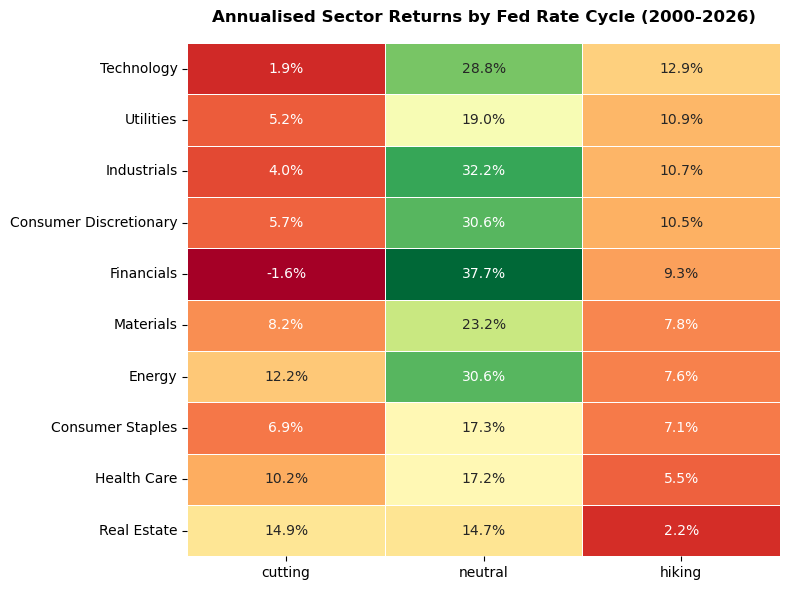

In [7]:
# Save a PNG version of the heatmap for the website
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1%',
    cmap='RdYlGn',
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)
ax.set_title('Annualised Sector Returns by Fed Rate Cycle (2000-2026)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../docs/figures/sector_cycle_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### What the heatmap shows

Two patterns stand out.

**The hiking and cutting columns are roughly mirror images.** Sectors that lead in hiking tend to lag in cutting, and vice versa. Real Estate is the clearest case, at 2.2% in hiking and 14.9% in cutting (the highest cutting cell in the table). Financials shows the same flip at the other end, leading in hiking at 9.3% and posting the only negative figure in cutting at -1.6%.

**The neutral column is the highest for nine of the ten sectors.** That isn't really telling us anything about how sectors behave in neutral periods. The 41 months in the neutral bucket happen to cluster in calm late-cycle bull runs that lifted almost everything, so the column ends up flattering every sector indiscriminately. Decision 5 explains why the bar chart in Section 5 drops neutral entirely.

The Real Estate cutting figure (14.9%) reflects the 2020 COVID episode alone, since XLRE did not exist during the 2001 or 2008-09 cutting cycles. Treat it as one event rather than a pattern.

## Section 6: Bar Chart, Hiking vs Cutting

The second visual is the headline finding. The heatmap above shows the full matrix; this strips it down to the comparison that actually answers the research question.

Neutral is left out here even though it appears in the heatmap (Decision 5). The 41-month neutral sample is too small and too clustered in late-cycle bull runs to support a confident regime comparison, and including it would dominate the chart and pull attention away from the contrast that matters.

Sectors are sorted left to right by hiking-cycle return (Decision 6) so the cyclical-to-defensive gradient reads naturally across the x-axis. Green is hiking and red is cutting, matching the heatmap colours so the eye carries the association across.

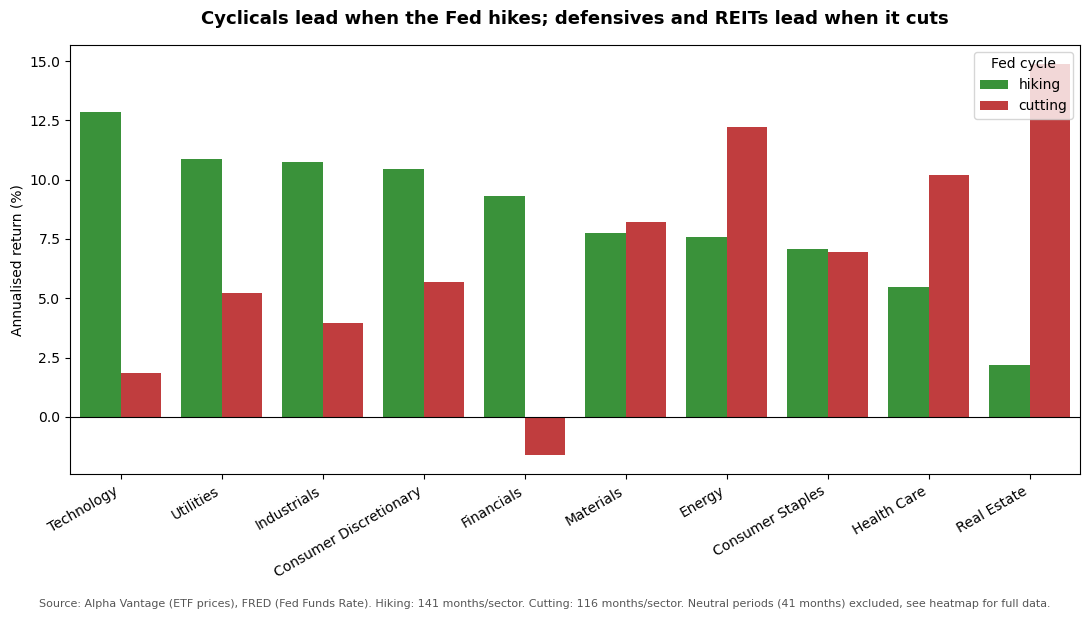

In [8]:
# Save the analysis outputs folder if it doesn't exist
import os
os.makedirs('../data/processed/analysis', exist_ok=True)
os.makedirs('../docs/figures', exist_ok=True)

# Save the cycle_returns and pivot CSVs so they can be reused
cycle_returns.to_csv('../data/processed/analysis/cycle_returns.csv', index=False)
pivot.to_csv('../data/processed/analysis/sector_cycle_pivot.csv')

# Prepare the plot dataframe (W09 plot_df pattern)
plot_df = (
    cycle_returns
    .assign(annualised_pct=lambda d: d['annualised_return'] * 100)
    [['sector', 'rate_cycle', 'annualised_pct']]
)

# Drop neutral for the headline chart (Decision 5)
plot_df = plot_df[plot_df['rate_cycle'].isin(['hiking', 'cutting'])]

# Sort sectors left-to-right by hiking-cycle performance (Decision 6)
sector_order = (
    plot_df[plot_df['rate_cycle'] == 'hiking']
    .sort_values('annualised_pct', ascending=False)['sector']
    .tolist()
)

cycle_order = ['hiking', 'cutting']

# Plot
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=plot_df,
    x='sector', y='annualised_pct',
    hue='rate_cycle',
    order=sector_order,
    hue_order=cycle_order,
    palette={'hiking': '#2ca02c', 'cutting': '#d62728'}
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Cyclicals lead when the Fed hikes; defensives and REITs lead when it cuts',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Annualised return (%)')
ax.tick_params(axis='x', rotation=30)
plt.setp(ax.get_xticklabels(), ha='right')
ax.legend(title='Fed cycle', loc='upper right')

# Source footnote
plt.figtext(
    0.5, -0.02,
    'Source: Alpha Vantage (ETF prices), FRED (Fed Funds Rate). '
    'Hiking: 141 months/sector. Cutting: 116 months/sector. '
    'Neutral periods (41 months) excluded, see heatmap for full data.',
    ha='center', fontsize=8, color='#555'
)

plt.tight_layout()
plt.savefig('../docs/figures/sector_returns_by_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

### What the chart shows

The pattern splits cleanly along sector cyclicality.

**Cyclicals lead in hiking cycles.** Technology, Utilities, Industrials, Consumer Discretionary and Financials all post higher annualised returns when the Fed is hiking than when it is cutting. Technology and Financials show the widest gap (around 11 percentage points each), and Financials is the only sector with a negative cutting-cycle return.

**Defensives and Real Estate lead in cutting cycles.** Health Care and Real Estate flip the other way, with cutting-cycle returns above their hiking-cycle returns. Consumer Staples is roughly flat across the two regimes.

**The middle sectors are mixed.** Materials and Energy sit between the two camps with broadly similar returns in both regimes. Energy in particular has a high cutting-cycle figure at 12.2%, which lines up with energy prices spiking during some of the crisis-driven easing periods in the sample.

This is the cyclical-defensive rotation pattern the research question was asking about, and it shows up in the chart without any further statistical work. Two things to flag before reading too much into the magnitudes: the cutting cycles in the sample (2001, 2008-09, 2020) were all crisis-driven, which inflates the defensive and Real Estate cutting-cycle returns, and the Real Estate cutting figure is the 2020 episode alone (Section 4 caveat). The next visual shows when each regime actually happened, which makes the crisis-driven point easier to see.

## Section 7: Fed Funds Rate with Regime Shading

The third visual is the macro context. The heatmap and bar chart show what each regime produced; this chart shows when each regime happened, which matters because the three cutting cycles in the sample (2001, 2008-09, 2020) all line up with recessions. That is the central caveat of the whole analysis: cutting-cycle returns here reflect crisis dynamics rather than normal monetary easing, and the only way to make that obvious to a reader is to show them the timeline.

A few design choices:

- One series on the y-axis (Fed Funds Rate). Adding CPI or yield spread on a twin axis would dilute the point, which is to make the regime classification visible.
- The regime is shown as background shading rather than a separate panel, so the cycle label sits visually under the rate path.
- Neutral periods are kept here even though they were dropped from the bar chart. Showing how short they are visually justifies the exclusion downstream.
- The three crisis episodes are annotated directly on the chart. A non-specialist reader needs to see that every cut in this sample coincides with a recession, otherwise the unusual cutting-cycle returns won't make sense.

**Quick note on what the shading shows.** The rate_cycle labels come from NB02's rolling-mean rule, and plotting them over time reveals a feature of the rule that the cycle counts in Section 1 didn't show. During flat-rate periods (most visibly 2010-2015 and 2021-2022), small month-to-month wobbles in the data flip the classification between hiking and cutting on consecutive months. The labelling is noisy whenever rates aren't really moving.

This is documented in repo Issue #9 and discussed below the chart. The aggregated results in Sections 4 and 5 are not materially affected because each regime cell averages over 100+ months and the misclassifications happen during low-volatility periods where the misallocated returns are small.

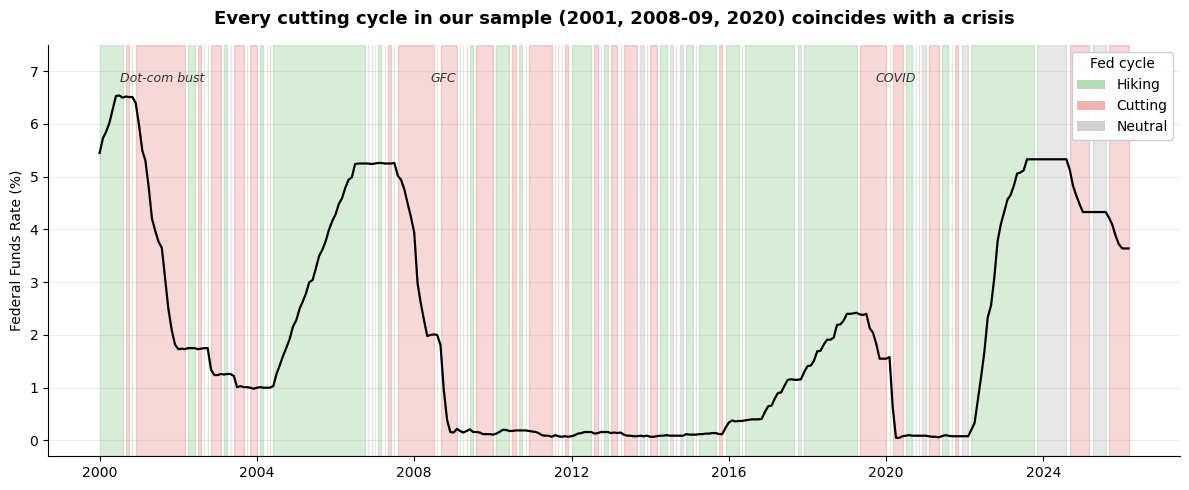

In [9]:
from matplotlib.patches import Patch

# Collapse to one row per month (df has 10 sector rows per date)
macro = (
    df[['date', 'fed_funds', 'rate_cycle']]
    .drop_duplicates('date')
    .sort_values('date')
    .reset_index(drop=True)
)

# Detect contiguous regime runs so each is shaded as one block
# rather than 300+ separate single-month bands
macro['run_id'] = (macro['rate_cycle'] != macro['rate_cycle'].shift()).cumsum()
runs = (
    macro.groupby(['run_id', 'rate_cycle'], as_index=False)
         .agg(start=('date', 'min'), end=('date', 'max'))
)

fig, ax = plt.subplots(figsize=(12, 5))
cycle_colors = {'hiking': '#2ca02c', 'cutting': '#d62728', 'neutral': '#7f7f7f'}

# Shaded regime bands behind the line
for _, run in runs.iterrows():
    ax.axvspan(run['start'], run['end'],
               color=cycle_colors[run['rate_cycle']], alpha=0.18)

# Fed Funds line on top
ax.plot(macro['date'], macro['fed_funds'], color='black', linewidth=1.6)

# Annotate the three crisis-era cutting cycles
for date_str, label in [('2001-08-01', 'Dot-com bust'),
                         ('2008-10-01', 'GFC'),
                         ('2020-04-01', 'COVID')]:
    ax.annotate(label, xy=(pd.Timestamp(date_str), 6.8),
                ha='center', fontsize=9, color='#333', fontstyle='italic')

# Manual legend for the shading (axvspan doesn't auto-legend)
legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.35, label='Hiking'),
    Patch(facecolor='#d62728', alpha=0.35, label='Cutting'),
    Patch(facecolor='#7f7f7f', alpha=0.35, label='Neutral'),
]
ax.legend(handles=legend_elements, title='Fed cycle',
          loc='upper right', framealpha=0.95)

ax.set_title('Every cutting cycle in our sample (2001, 2008-09, 2020) coincides with a crisis',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Federal Funds Rate (%)')
ax.set_xlabel('')
ax.set_ylim(-0.3, 7.5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('../docs/figures/fed_funds_cycles.png', dpi=150, bbox_inches='tight')
plt.show()

### What the chart shows

**The three cutting regimes line up with the three recessions in the sample.** The first dominant red block at 2001-2003 is the dot-com bust, the second at 2007-2009 is the GFC, and the third in 2020 is COVID. The Fed didn't cut rates in this sample without a crisis driving the decision. That is the central caveat of the bar chart and heatmap: cutting-cycle returns reflect three crisis episodes rather than three normal monetary easings, and any reading of "how sectors perform in a Fed cutting cycle" should really be read as "how sectors perform when the Fed is cutting in a recession."

**The shading is noisy during flat-rate periods.** This isn't a finding about the economy, it's a finding about the labelling rule. Where the Fed held rates flat (most of 2010-2015 at the zero lower bound, and 2021-2022 around the same level), small wobbles flipped the rolling-mean signal back and forth. The aggregated returns earlier are robust to this, but the timeline makes the limitation visible in a way the cycle-count summary didn't.

Together these two points are why the analysis hedges the way it does. The cutting-cycle returns are crisis-conditioned rather than regime-conditioned in any clean theoretical sense, and the regime labels themselves carry classification noise during periods when nothing much is happening to rates. Both points feed forward into the limitations summary in Section 8.

## Section 8: Saving Analysis Outputs

The two CSVs and the three figures are saved as the bar chart and Fed Funds chart cells run, but it's worth being explicit about what's leaving the notebook and where.

| Output | Path | Used by |
|--------|------|---------|
| `cycle_returns.csv` | `data/processed/analysis/` | Anyone reproducing the heatmap or bar chart |
| `sector_cycle_pivot.csv` | `data/processed/analysis/` | The website, if it imports the pivot directly |
| `sector_returns_by_cycle.png` | `docs/figures/` | Website embed |
| `fed_funds_cycles.png` | `docs/figures/` | Website embed |

Two CSVs rather than one because they serve different jobs: `cycle_returns.csv` is the long-format table with mean/median/std/n_months per sector-cycle, useful for any reader who wants to recompute or extend the analysis. `sector_cycle_pivot.csv` is the wide-format heatmap-ready table, which is the format the website needs if it embeds the table rather than the image.

## Section 9: Summary and Limitations

### What the analysis found

Across 2000-2026, US equity sector returns split cleanly along sector cyclicality when grouped by Fed rate regime. Cyclical sectors (Technology, Utilities, Industrials, Consumer Discretionary, Financials) earned higher annualised returns when the Fed was hiking than when it was cutting. Defensives (Health Care, Consumer Staples) and Real Estate showed the opposite pattern, with cutting-cycle returns above their hiking-cycle returns. Energy and Materials sit between the two camps with broadly similar returns in both regimes.

The cyclical-defensive flip between regimes is the central finding. It's visible in the heatmap, sharpened in the bar chart, and contextualised by the Fed Funds timeline.

### Limitations

Four limitations apply, each of which has been flagged at the point in the notebook where it matters most.

**1. Cutting cycles in the sample are all crisis-driven.** The three cutting cycles in the data (2001 dot-com bust, 2008-09 GFC, 2020 COVID) all coincide with US recessions. Cutting-cycle returns here reflect crisis dynamics rather than normal monetary easing. A sample including a soft-landing cut would likely look different. This is the most important caveat and is visualised directly in Section 6.

**2. Real Estate has a short ETF history.** XLRE launched in October 2015 and has 124 observations versus 315 for every other sector. Its cutting-cycle figure

## Section 10: Export Data for Website's Interactive Charts

The companion website (`docs/index.html`) renders Findings 1, 2 and 3 as interactive Plotly charts. Finding 3's chart needs the Fed Funds Rate monthly time series and the contiguous regime runs derived in this notebook. This cell exports both as JavaScript constants ready to paste into the inline `<script>` block in the website.

Re-running this cell regenerates the export if the underlying pipeline changes. The constants are pasted into `docs/index.html` rather than fetched at runtime because the static GitHub Pages host doesn't serve database files cleanly for browser-side fetching.

In [11]:
# Section 10 · Export data for the website's interactive charts
# 
# The docs/index.html page renders Findings 1, 2 and 3 as interactive Plotly
# charts. The data behind those charts is exported here as JS constants and
# pasted into the inline <script> blocks. To regenerate the website data after
# a pipeline change, re-run this cell and update the constants in docs/index.html.

import json

# Fed Funds Rate time series for Finding 3
macro_export = df[['date', 'fed_funds', 'rate_cycle']].drop_duplicates('date').sort_values('date').reset_index(drop=True)
macro_export['run_id'] = (macro_export['rate_cycle'] != macro_export['rate_cycle'].shift()).cumsum()

runs_df = (
    macro_export.groupby(['run_id', 'rate_cycle'], as_index=False)
                .agg(start=('date', 'min'), end=('date', 'max'))
)

# Print as JS constants ready to paste into docs/index.html
print("// === Fed Funds Rate monthly series ===")
print("var ffDates =", json.dumps(macro_export['date'].dt.strftime('%Y-%m-%d').tolist()) + ";")
print()
print("var ffRates =", json.dumps(macro_export['fed_funds'].tolist()) + ";")
print()
print("// === Regime runs (contiguous blocks of hiking/cutting/neutral) ===")
print("var ffRuns =", json.dumps([
    {'regime': r['rate_cycle'],
     'start': r['start'].strftime('%Y-%m-%d'),
     'end': r['end'].strftime('%Y-%m-%d')}
    for _, r in runs_df.iterrows()
]) + ";")

// === Fed Funds Rate monthly series ===
var ffDates = ["2000-01-01", "2000-02-01", "2000-03-01", "2000-04-01", "2000-05-01", "2000-06-01", "2000-07-01", "2000-08-01", "2000-09-01", "2000-10-01", "2000-11-01", "2000-12-01", "2001-01-01", "2001-02-01", "2001-03-01", "2001-04-01", "2001-05-01", "2001-06-01", "2001-07-01", "2001-08-01", "2001-09-01", "2001-10-01", "2001-11-01", "2001-12-01", "2002-01-01", "2002-02-01", "2002-03-01", "2002-04-01", "2002-05-01", "2002-06-01", "2002-07-01", "2002-08-01", "2002-09-01", "2002-10-01", "2002-11-01", "2002-12-01", "2003-01-01", "2003-02-01", "2003-03-01", "2003-04-01", "2003-05-01", "2003-06-01", "2003-07-01", "2003-08-01", "2003-09-01", "2003-10-01", "2003-11-01", "2003-12-01", "2004-01-01", "2004-02-01", "2004-03-01", "2004-04-01", "2004-05-01", "2004-06-01", "2004-07-01", "2004-08-01", "2004-09-01", "2004-10-01", "2004-11-01", "2004-12-01", "2005-01-01", "2005-02-01", "2005-03-01", "2005-04-01", "2005-05-01", "2005-06-01", "2005-07-01", "2005-